In [1]:
import os
print("Directorio actual:", os.getcwd())
print("Archivos en este directorio:", os.listdir())

Directorio actual: /root/tickets-mlp/model-training/export_model
Archivos en este directorio: ['model_v1.joblib', '.ipynb_checkpoints', 'export_model.ipynb', '__pycache__', 'preprocesamiento.py']


In [2]:
# ============================================
# PIPELINE COMPLETO: preprocesamiento + escalado + modelo
# Reemplaza toda la seccion de one-hot manual, mapeo de Afectados,
# escalado y entrenamiento.
# ============================================
 
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from preprocesamiento import AfectadosTransformer

In [3]:
# --------------------------------------------
# 1. Cargar dataset (igual que antes)
# --------------------------------------------
df_orig = pd.read_csv("../dataset.csv")
df = df_orig.copy()

In [4]:
# --------------------------------------------
# 3. ColumnTransformer: define que transformacion aplicar a cada columna
#    - Pabellon, Laboratorio, Categoria, Subcategoria -> One-Hot Encoding
#    - Afectados -> nuestro transformador personalizado
# --------------------------------------------
preprocesador = ColumnTransformer(
    transformers=[
        ('nominales', OneHotEncoder(handle_unknown='ignore'),
         ['Pabellon', 'Laboratorio', 'Categoria', 'Subcategoria']),
        ('afectados', AfectadosTransformer(), ['Afectados']),
    ],
    remainder='drop'  # descarta cualquier columna no mencionada explicitamente
)

In [5]:
# --------------------------------------------
# 4. Pipeline completo: preprocesamiento + escalado + MLP
#    with_mean=False porque el One-Hot genera una matriz dispersa (sparse)
# --------------------------------------------
pipeline_completo = Pipeline([
    ('preprocesamiento', preprocesador),
    ('escalado', StandardScaler(with_mean=False)),
    ('modelo', MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    ))
])

In [6]:
# --------------------------------------------
# 5. Separar X e y (el target sigue siendo texto: Baja/Media/Alta)
#    Ya no es necesario mapear Criticidad a numeros a mano,
#    el propio modelo de sklearn puede trabajar con las etiquetas de texto directamente
# --------------------------------------------
X = df.drop(columns=['Criticidad'])
y = df['Criticidad']
 
# --------------------------------------------
# 6. Train/test split 
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
 
print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)

Entrenamiento: (240, 5) (240,)
Prueba: (60, 5) (60,)


In [7]:
# --------------------------------------------
# 7. Entrenar el pipeline completo (hace TODO: preprocesa + escala + entrena)
# --------------------------------------------
pipeline_completo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('escalado', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U5](3,)","['Alta','Baja','Media']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Pabellon','Laboratorio','Categoria','Subcategoria','Afectados']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nominales', ...), ('afectados', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [8]:
# --------------------------------------------
# 8. Evaluar
# --------------------------------------------
y_pred = pipeline_completo.predict(X_test)
 
print(classification_report(y_test, y_pred, target_names=['Baja', 'Media', 'Alta']))

              precision    recall  f1-score   support

        Baja       1.00      0.95      0.97        20
       Media       1.00      0.85      0.92        20
        Alta       0.83      1.00      0.91        20

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



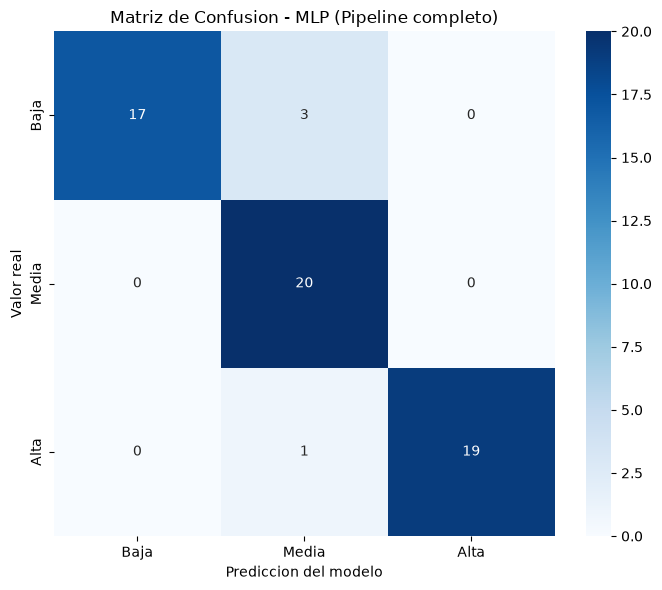

In [9]:
# --------------------------------------------
# 9. Matriz de confusion
# --------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
 
cm = confusion_matrix(y_test, y_pred, labels=['Baja', 'Media', 'Alta'])
 
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Baja', 'Media', 'Alta'],
    yticklabels=['Baja', 'Media', 'Alta']
)
plt.xlabel('Prediccion del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de Confusion - MLP (Pipeline completo)')
plt.tight_layout()
plt.show()

In [10]:
# --------------------------------------------
# 10. Exportar el pipeline completo en UN SOLO ARCHIVO
#     Este archivo ya incluye: one-hot, tratamiento de Afectados,
#     escalado y el modelo entrenado. 
# --------------------------------------------
import joblib
import os

joblib.dump(pipeline_completo, "model_v1.joblib")
 
print("\nPipeline exportado en: export_model/model_v1.joblib")


Pipeline exportado en: export_model/model_v1.joblib


In [11]:
# ============================================
# Copiar artefactos hacia model-api/
# ============================================
import shutil
import os

ruta_model_api = "../../model-api"

# Copiar el archivo de preprocesamiento
shutil.copy("preprocesamiento.py", os.path.join(ruta_model_api, "preprocesamiento.py"))

# Copiar el modelo entrenado
shutil.copy("model_v1.joblib", os.path.join(ruta_model_api, "model_v1.joblib"))

print("Archivos copiados correctamente hacia:", os.path.abspath(ruta_model_api))
print(" - preprocesamiento.py")
print(" - model_v1.joblib")

Archivos copiados correctamente hacia: /root/tickets-mlp/model-api
 - preprocesamiento.py
 - model_v1.joblib
